# Classification after Clustering with Agglomerative Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score


pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"./data/clustered_data.csv")
# Print shape of dataset
print(df.shape)



(2240, 22)


# x and y split

In [2]:
X = df.drop('cluster', axis=1)
y =df['cluster']

In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print('Null values in X:', X.isnull().sum().sum())  # should print 0

Null values in X: 0


## Grid Search

- Why do we use Grid Search?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.

## Select the best model
- so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, \
    confusion_matrix , precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics



models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

we will be creating a genric functions to check accuracy of each model

def

In [5]:
def evaluate_model(X, y, models):
     '''
     This function takes in X and y and models dictionary as input
     It splits the data into Train Test split
     Iterates through the given model dictionary and evaluates the metrics
     Returns: Dataframe which contains report of all models metrics with cost
     '''
     # Train Test Split
     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

     # Empty list to store the report of all models
     models_list = []
     scores = []

     for model_name, model in models.items():
          model.fit(X_train, y_train)

          # make predictions
          y_pred = model.predict(X_test)
          score = accuracy_score(y_test, y_pred)

          print(f'---- score for --- {model_name} ----')
          print(f"{score}")
          models_list.append(model_name)
          scores.append(score)

     print()

     report = pd.DataFrame()
     report['Model_name'] = models_list
     report['Score'] = scores
     return report


In [6]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier

report = evaluate_model(X, y, models)

---- score for --- Random Forest ----
0.96875
---- score for --- Decision Tree ----
0.9397321428571429
---- score for --- Gradient Boosting ----
0.9620535714285714
---- score for --- Logistic Regression ----
0.8772321428571429
---- score for --- K-Neighbors Classifier ----
0.8080357142857143
---- score for --- XGBClassifier ----
0.96875
---- score for --- CatBoosting Classifier ----
0.9732142857142857
---- score for --- AdaBoost Classifier ----
0.9375



In [7]:
X.isnull().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total Promo           0
NumWebVisitsMonth     0
dtype: int64

In [8]:
report.sort_values(by='Score', ascending=False)

,Model_name,Score
6,CatBoosting Classifier,0.973214
0,Random Forest,0.968750
5,XGBClassifier,0.968750
2,Gradient Boosting,0.962054
1,Decision Tree,0.939732
7,AdaBoost Classifier,0.937500
3,Logistic Regression,0.877232
4,K-Neighbors Classifier,0.808036


# From the above catboosting classifer as performed the best so we will be using it to train our model


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# HYPER PARAMETER TUNING


In [33]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

params = {
    'depth': [4, 6, 8, 10],
    'learning_rate': np.logspace(-3, 0, 4),
    'iterations': np.random.randint(100, 500, 5).tolist(),
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

catboost = CatBoostClassifier(verbose=0, random_state=42)

catboost_cv = RandomizedSearchCV(catboost, params, 
                                  n_iter=20,  # only tries 20 random combinations
                                  cv=5,       # 5 folds instead of 10
                                  scoring='accuracy', 
                                  random_state=42,
                                  n_jobs=-1)
catboost_cv.fit(X_train, y_train)

print("tuned hpyerparameters :(best parameters) ", catboost_cv.best_params_)
print("accuracy :", catboost_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'learning_rate': np.float64(1.0), 'l2_leaf_reg': 1, 'iterations': 249, 'depth': 4, 'border_count': 32}
accuracy : 0.9737663590669301


In [34]:
best_catboost_model = CatBoostClassifier(
    learning_rate=1.0,
    l2_leaf_reg=1,
    iterations=249,
    depth=4,
    border_count=32,
    verbose=0,
    random_state=42
)

best_catboost_model.fit(X_train, y_train)
y_pred = best_catboost_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9754464285714286
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       167
           1       0.98      0.97      0.98       127
           2       0.96      0.98      0.97       154

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448



In [35]:
best_model = best_catboost_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("CatBoost Classifier")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

CatBoost Classifier
Accuracy Score value: 0.9754
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       167
           1       0.98      0.97      0.98       127
           2       0.96      0.98      0.97       154

    accuracy                           0.98       448
   macro avg       0.98      0.98      0.98       448
weighted avg       0.98      0.98      0.98       448



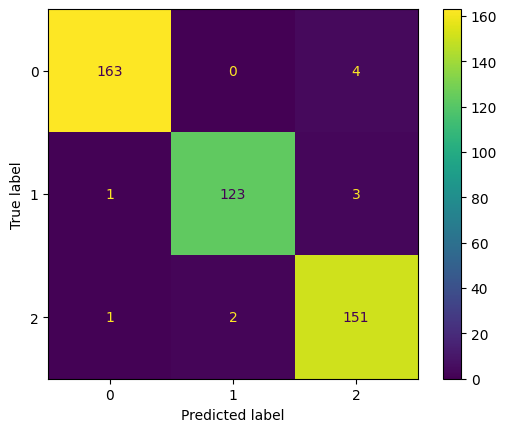

In [36]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

# WE GOT EVERYTHING FOR CATRBOOSTING

In [1]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient

load_dotenv()
client = MongoClient(os.getenv("MONGO_DB_URL"))

In [12]:
import pickle

if not hasattr(catboost_cv, "best_estimator_"):
    catboost_cv.fit(X_train, y_train)

best_model = catboost_cv.best_estimator_

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
